In [2]:
import os
import ast
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELS     = CONFIGS['experiments']
SPLIT      = 'test'

SR_GAUSS_FIELDVARS = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NN_SEEDS           = MODELS['nn']['seeds']
OPTIMIZEDEQS       = MODELS['sr']['optimizedeqs']
PODRUNS            = MODELS['pod']['runs']
NNRUNS             = MODELS['nn']['runs']
ORDER              = ['pod_bl','nn_bl','nn_full','nn_nonparam','nn_gauss','sr_lo','sr_bl','sr_med','sr_hi']

COLORS = {}
LABELS = {}
for name,cfg in {**PODRUNS,**NNRUNS,**OPTIMIZEDEQS}.items():
    COLORS[name] = cfg['color']
    LABELS[name] = cfg['description']

NBINS   = 20
MINSAMP = 30

In [4]:
def kernel_integrate(fields,weights,dsig,mask=None):
    w = fields*weights[None,:,:]*dsig[None,None,:]
    if mask is not None:
        w = w*mask[:,None,:]
    return w.sum(axis=2)

def to_phys(srout):
    return np.expm1(tpstd*np.maximum(0.0,np.asarray(srout,dtype=float)))

SRFUNCTIONS = {
    'cube':lambda x:x**3,
    'square':lambda x:x**2,
    'neg':lambda x:-x,
    'sqrt':np.sqrt,
    'exp':np.exp,
    'log':np.log,
    'abs':np.abs,
    'max':np.maximum,
    'min':np.minimum}

def eval_form(form,variables,constants):
    ns = dict(SRFUNCTIONS)
    ns.update(variables)
    ns.update(constants)
    return np.asarray(eval(form,{'__builtins__':{}},ns),dtype=float)

def used_predictors(form,candidates):
    names = {n.id for n in ast.walk(ast.parse(form,mode='eval')) if isinstance(n,ast.Name)}
    return [c for c in candidates if c in names]

def bin1d(x,z,nbins=NBINS,minsamp=MINSAMP,plo=1,phi=99):
    '''Binned mean of z vs x using evenly-spaced value bins (not quantile bins).'''
    finite = np.isfinite(x)&np.isfinite(z)
    x,z    = x[finite],z[finite]
    lo,hi  = np.percentile(x,[plo,phi])
    edges  = np.linspace(lo,hi,nbins+1)
    xi     = np.clip(np.digitize(x,edges)-1,0,nbins-1)
    means  = np.full(nbins,np.nan)
    for i in range(nbins):
        sel = xi==i
        if sel.sum()>=minsamp:
            means[i] = z[sel].mean()
    return 0.5*(edges[:-1]+edges[1:]),means

def bin2d(x,y,z,nbins=NBINS,minsamp=MINSAMP,plo=1,phi=99):
    '''Binned mean of z vs (x,y) using evenly-spaced 2D value bins (not quantile bins).'''
    finite  = np.isfinite(x)&np.isfinite(y)&np.isfinite(z)
    x,y,z   = x[finite],y[finite],z[finite]
    xlo,xhi = np.percentile(x,[plo,phi])
    ylo,yhi = np.percentile(y,[plo,phi])
    xedges  = np.linspace(xlo,xhi,nbins+1)
    yedges  = np.linspace(ylo,yhi,nbins+1)
    xi      = np.clip(np.digitize(x,xedges)-1,0,nbins-1)
    yi      = np.clip(np.digitize(y,yedges)-1,0,nbins-1)
    flatidx = xi*nbins+yi
    sums    = np.bincount(flatidx,weights=z,minlength=nbins*nbins).reshape(nbins,nbins)
    counts  = np.bincount(flatidx,minlength=nbins*nbins).reshape(nbins,nbins)
    means   = np.where(counts>=minsamp,sums/np.maximum(counts,1),np.nan)
    return 0.5*(xedges[:-1]+xedges[1:]),0.5*(yedges[:-1]+yedges[1:]),means,counts

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
tpmean = float(STATS['tp_mean'])
tpstd  = float(STATS['tp_std'])
zmin   = (0.0-tpmean)/tpstd

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = ds.sizes['time'],ds.sizes['lat'],ds.sizes['lon']
    nsig            = ds.sizes.get('sig',1)
    dsig            = ds['dsig'].values
    farrs      = [ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in SR_GAUSS_FIELDVARS]
    fieldstack = np.stack(farrs,axis=1)
    surfmask   = (ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  if 'surfmask' in ds else None)
    def getflat(da):
        if 'time' in da.dims:
            return da.transpose('time','lat','lon').values.ravel()
        return np.tile(da.values,(ntime,1,1)).ravel()
    blnorm  = getflat(ds['bl'])
    lfnorm  = getflat(ds['lf'])
    shfnorm = getflat(ds['shf'])
    lhfnorm = getflat(ds['lhf'])

kwlist = []
for seed in NN_SEEDS:
    wpath = os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            kwlist.append(wds['k'].values)

ki = np.mean([kernel_integrate(fieldstack,kw,dsig,surfmask) for kw in kwlist],axis=0) if kwlist else fieldstack.mean(axis=2)
rhk,thetaek,thetaestark = ki[:,0],ki[:,1],ki[:,2]

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsflat = ds.tp.transpose('time','lat','lon').values.ravel()

with open(os.path.join(MODELSDIR,'sr','optimized_equations.pkl'),'rb') as f:
    SR_REGISTRY = pickle.load(f)

In [6]:
VARS = {'bl':blnorm,'rh':rhk,'thetae':thetaek,'thetaestar':thetaestark,'lf':lfnorm,'shf':shfnorm,'lhf':lhfnorm}

MODELPRED = {}
MODELPREDICTORS = {}
for name,cfg in OPTIMIZEDEQS.items():
    entry          = SR_REGISTRY.get(name,{})
    form           = entry.get('form',cfg['form'])
    constants      = entry.get('constants',cfg['init'])
    predictornames = used_predictors(form,VARS.keys())
    variables      = {p:VARS[p] for p in predictornames}
    formvals       = eval_form(form,variables,constants)
    MODELPRED[name]       = to_phys(formvals)
    MODELPREDICTORS[name] = predictornames

In [7]:
def load_predictions(name,predsdir,split=SPLIT):
    '''Load saved POD/NN predictions (averaged across seeds if present), flattened to match obsflat.'''
    filepath = os.path.join(predsdir,f'{name}_{split}_predictions.nc')
    if not os.path.exists(filepath):
        return None
    with xr.open_dataset(filepath,engine='h5netcdf') as ds:
        da = ds['tp'].load()
    if 'seed' in da.dims:
        da = da.mean('seed')
    return da.transpose('time','lat','lon').values.ravel()

for name,cfg in PODRUNS.items():
    pred = load_predictions(name,PREDSDIR)
    if pred is None:
        continue
    MODELPRED[name]       = pred
    MODELPREDICTORS[name] = [cfg['inputvar']]

for name,cfg in NNRUNS.items():
    pred = load_predictions(name,PREDSDIR)
    if pred is None:
        continue
    MODELPRED[name]       = pred
    MODELPREDICTORS[name] = cfg['fieldvars']+cfg.get('localvars',[])

print(f'Loaded predictions for: {sorted(MODELPRED.keys())}')

Loaded predictions for: ['nn_bl', 'nn_full', 'nn_gauss', 'nn_nonparam', 'pod_bl', 'sr_bl', 'sr_hi', 'sr_lo', 'sr_med']


In [8]:
PHYSUNITS  = {'bl':'m/s$^2$','rh':'%','thetae':'K','thetaestar':'K','lf':'0-1','shf':'W/m$^2$','lhf':'W/m$^2$'}
PHYSLABELS = {'bl':'BL','rh':'RH','thetae':r'$\theta_e$','thetaestar':r'$\theta_e^*$','lf':'LF','shf':'SHF','lhf':'LHF'}

PREDICTORS = []
for p in ['bl','rh','thetae','thetaestar','lf','shf','lhf']:
    models = [name for name in MODELPREDICTORS if name in MODELPRED and p in MODELPREDICTORS[name]]
    if models:
        PREDICTORS.append((p,models))

def models_for_pair(px,py):
    return [name for name in MODELPREDICTORS
            if name in MODELPRED and px in MODELPREDICTORS[name] and py in MODELPREDICTORS[name]]

valid = np.isfinite(obsflat)
for arr in VARS.values():
    valid &= np.isfinite(arr)
for arr in MODELPRED.values():
    valid &= np.isfinite(arr)

print(f'Valid samples: {valid.sum():,}')
print(PREDICTORS)

Valid samples: 1,437,408
[('bl', ['sr_bl', 'pod_bl', 'nn_bl']), ('rh', ['sr_lo', 'sr_med', 'sr_hi', 'nn_full', 'nn_nonparam', 'nn_gauss']), ('thetae', ['sr_med', 'sr_hi', 'nn_full', 'nn_nonparam', 'nn_gauss']), ('thetaestar', ['sr_med', 'sr_hi', 'nn_full', 'nn_nonparam', 'nn_gauss']), ('lf', ['sr_hi', 'nn_full', 'nn_nonparam', 'nn_gauss']), ('shf', ['sr_hi', 'nn_full', 'nn_nonparam', 'nn_gauss']), ('lhf', ['nn_full', 'nn_nonparam', 'nn_gauss'])]


In [18]:
def plot_dependence():
    ncols = 4
    nrows = -(-len(PREDICTORS)//ncols)
    fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,figwidth=6.5,sharex=False,sharey=True)
    for ax,(p,models) in zip(axs,PREDICTORS):
        x = VARS[p][valid]*STATS[f'{p}_std']+STATS[f'{p}_mean']
        xc,obsbin = bin1d(x,obsflat[valid])
        ax.plot(xc,obsbin,color='k',linewidth=2,label='Observed',zorder=5)
        for name in ORDER:
            if name not in models:
                continue
            _,predbin = bin1d(x,MODELPRED[name][valid])
            ax.plot(xc,predbin,color=COLORS[name],linewidth=1.5,label=LABELS[name])
        ax.format(grid=False,xlabel=f'{PHYSLABELS[p]} ({PHYSUNITS[p]})')
    for ax in axs[len(PREDICTORS):]:
        ax.set_visible(False)
    axs[:,0].format(ylabel='Precipitation (mm)',ylim=(0,5))
    handles = [Line2D([],[],color='k',linewidth=2,label='Observed')]
    handles += [Line2D([],[],color=COLORS[name],linewidth=1.5,label=LABELS[name]) for name in ORDER if name in MODELPRED]
    fig.legend(handles,loc='b',ncols=4)
    # fig.format(abc=True,abcloc='ul')
    pplt.show()

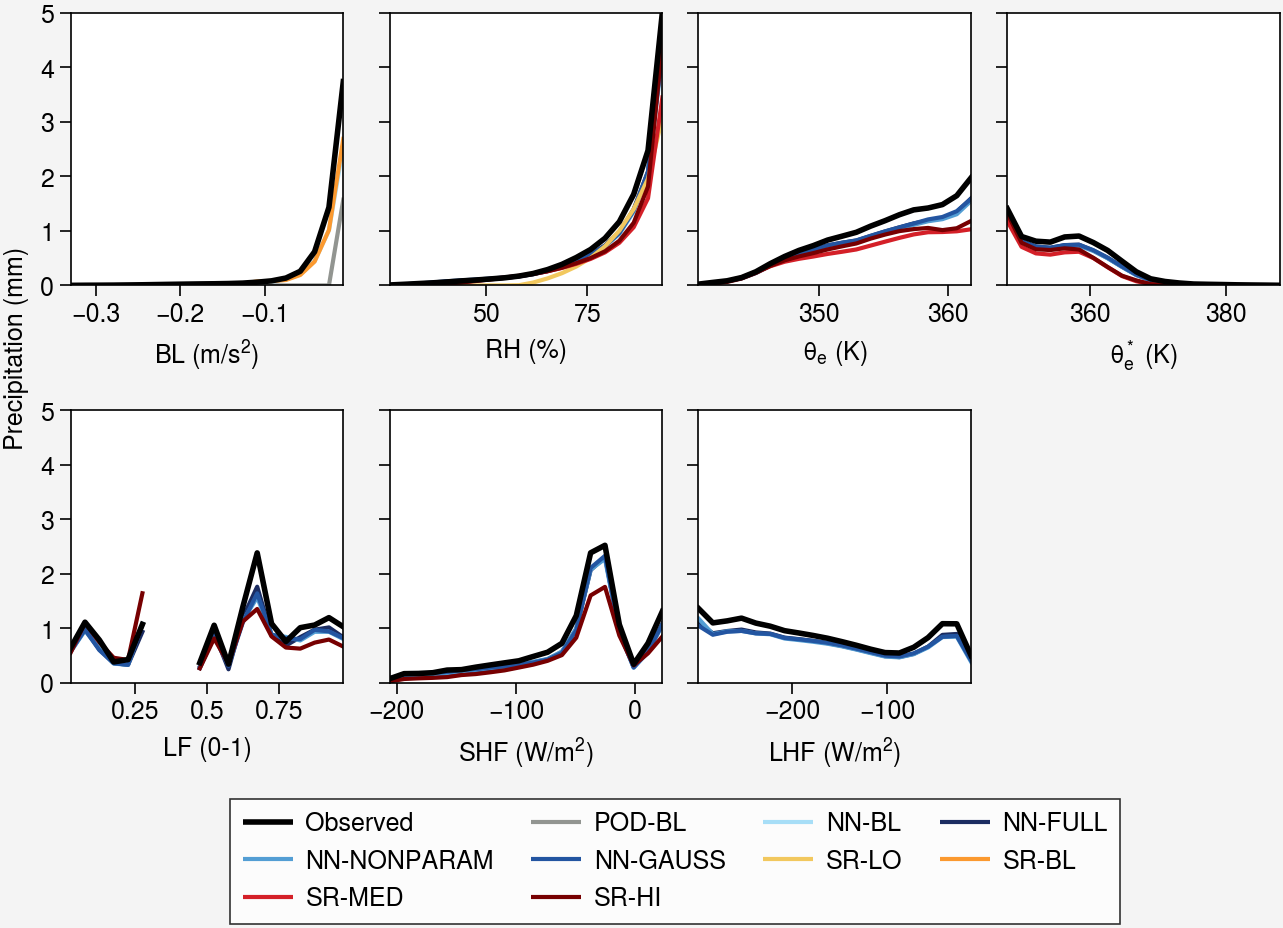

In [19]:
plot_dependence()

In [20]:
def plot_dependence2d(px,py):
    '''2D partial dependence: binned-mean precipitation over (px,py), one panel per model that uses both.'''
    models = [name for name in ORDER if name in models_for_pair(px,py)]
    panels = ['obs']+models
    x = VARS[px][valid]*STATS[f'{px}_std']+STATS[f'{px}_mean']
    y = VARS[py][valid]*STATS[f'{py}_std']+STATS[f'{py}_mean']
    fig,axs = pplt.subplots(nrows=1,ncols=len(panels),figwidth=1.6*len(panels),share=True)
    vmax = None
    for ax,name in zip(axs,panels):
        z = obsflat[valid] if name=='obs' else MODELPRED[name][valid]
        xc,yc,zbin2d,_ = bin2d(x,y,z)
        if vmax is None:
            vmax = np.nanpercentile(zbin2d,99)
        m = ax.pcolormesh(xc,yc,zbin2d.T,cmap='Blues',vmin=0,vmax=3,levels=21,extend='max')
        title = 'Observed' if name=='obs' else LABELS[name]
        ax.format(title=title,xlabel=f'{PHYSLABELS[px]} ({PHYSUNITS[px]})',grid=False)
    axs[0].format(ylabel=f'{PHYSLABELS[py]} ({PHYSUNITS[py]})')
    fig.colorbar(m,loc='r',label='Precipitation (mm)')
    pplt.show()

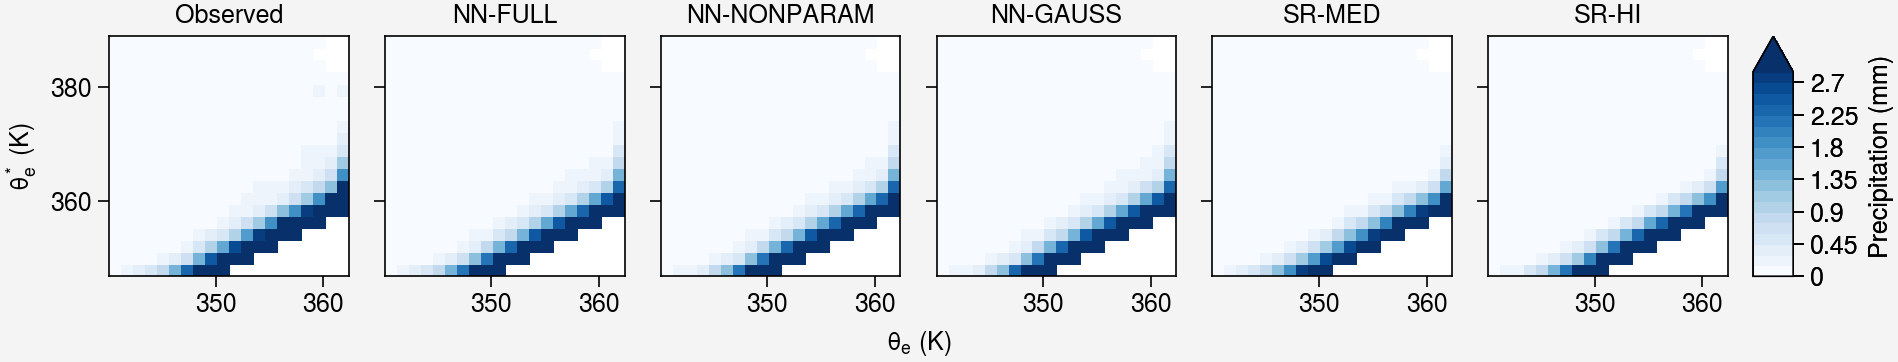

In [21]:
plot_dependence2d('thetae','thetaestar')

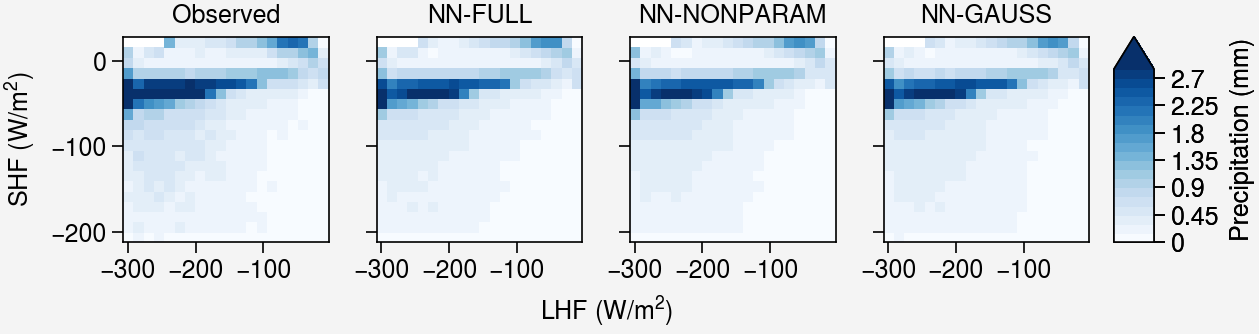

In [22]:
plot_dependence2d('lhf','shf')

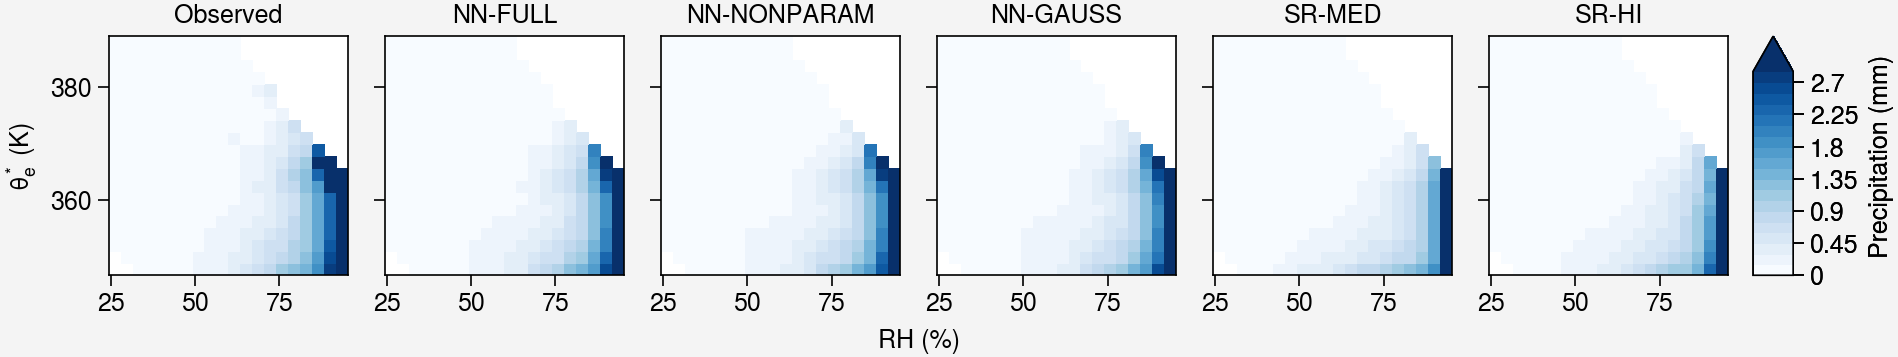

In [23]:
plot_dependence2d('rh','thetaestar')

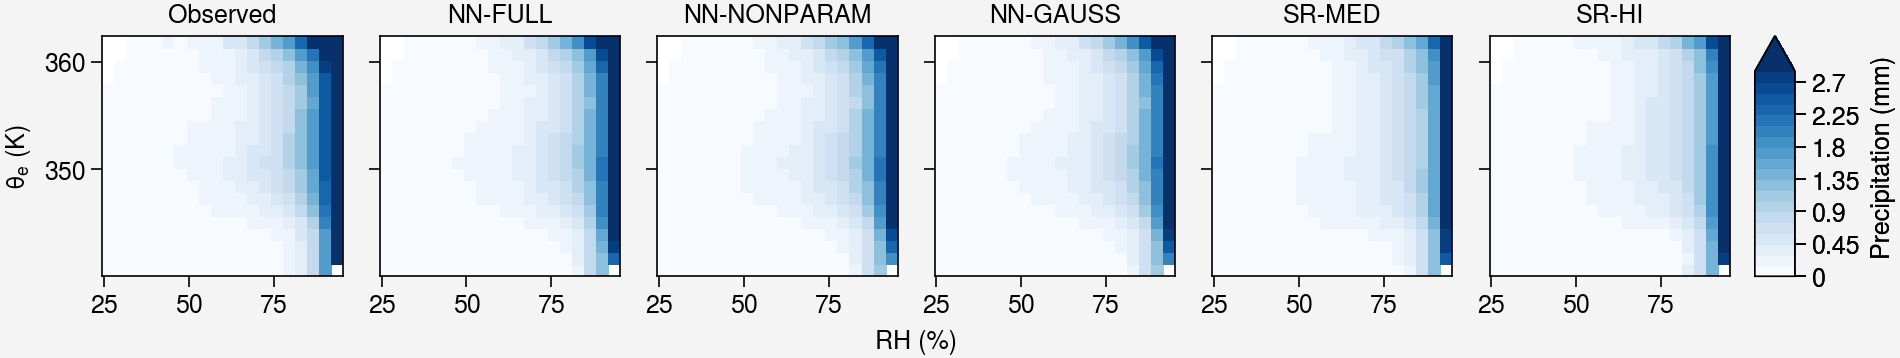

In [24]:
plot_dependence2d('rh','thetae')

## Exploring derived/raw surface variables for a smoother SR feature space

Observed-only dependence plots (no model curves) for candidate features computed from variables already
saved in `data/interim`/`data/splits` (`sst` is already saved alongside `lf`/`shf`/`lhf` but unused so far) —
used to check which surface representation is smoothest before choosing inputs for the next PySR search.

In [25]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    lfraw  = getflat(ds['lf'])
    shfraw = getflat(ds['shf'])
    lhfraw = getflat(ds['lhf'])

qnet  = lhfraw+shfraw # qnet = lhf + shf (surf enthalpy flux)
ef    = np.where(np.abs(qnet)>1.0,lhfraw/qnet,np.nan) # ef = lhf / (lhf + shf) , ranges 0-1
bowen = np.where(np.abs(lhfraw)>1.0,shfraw/lhfraw,np.nan) # bowen = shf / lhf

EXTRAVARS   = {'lf':lfraw,'shf':shfraw,'lhf':lhfraw,'ef':ef,'bowen':bowen,'qnet':qnet}
EXTRAUNITS  = {'lf':'0-1','shf':'W/m$^2$','lhf':'W/m$^2$','ef':'0-1','bowen':'0-1','qnet':'W/m$^2$'}
EXTRALABELS = {'lf':'LF','shf':'SHF','lhf':'LHF','ef':'EF','bowen':'Bowen ratio','qnet':r'$Q_{net}$'}

print(f'Candidate features: {sorted(EXTRAVARS.keys())}')

Candidate features: ['bowen', 'ef', 'lf', 'lhf', 'qnet', 'shf']


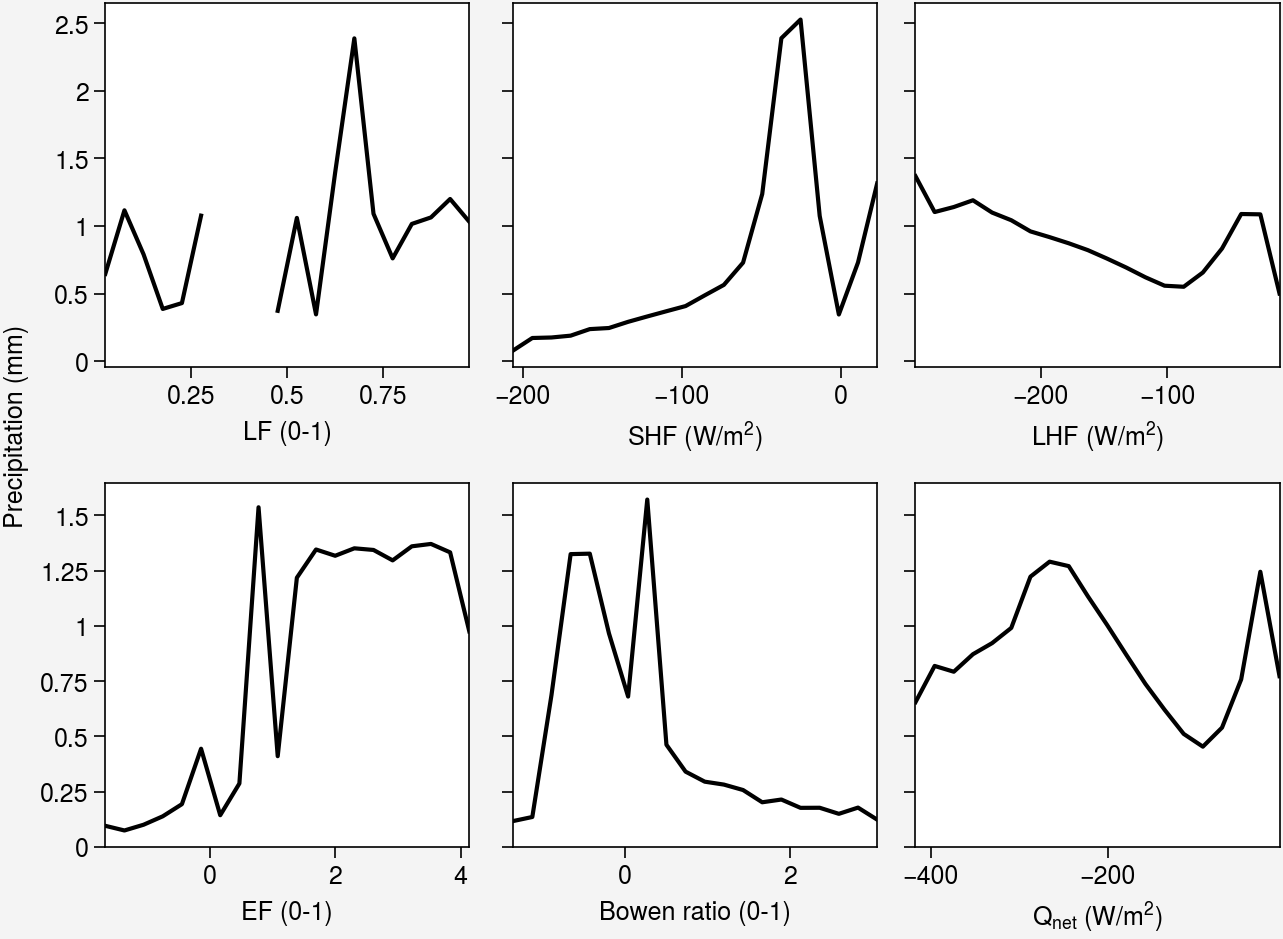

In [26]:
def plot_obs_dependence(varnames,savepath):
    ncols = 3
    nrows = -(-len(varnames)//ncols)
    fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,figwidth=6.5,sharex=False,sharey=True)
    for ax,p in zip(axs,varnames):
        xc,obsbin = bin1d(EXTRAVARS[p][valid],obsflat[valid])
        ax.plot(xc,obsbin,color='k',linewidth=1.5)
        ax.format(grid=False,xlabel=f'{EXTRALABELS[p]} ({EXTRAUNITS[p]})')
    for ax in axs[len(varnames):]:
        ax.set_visible(False)
    axs[:,0].format(ylabel='Precipitation (mm)')
    pplt.show()
    fig.save(savepath)
    return fig

fig_extra = plot_obs_dependence(['lf','shf','lhf','ef','bowen','qnet'],savepath='../figs/dependence_extra_obs.jpg')

In [27]:
def get_phys(p):
    if p in EXTRAVARS:
        return EXTRAVARS[p][valid],EXTRALABELS[p],EXTRAUNITS[p]
    return VARS[p][valid]*STATS[f'{p}_std']+STATS[f'{p}_mean'],PHYSLABELS[p],PHYSUNITS[p]

def plot_obs_dependence2d(px,py):
    '''Observed-only 2D partial dependence for a candidate (px,py) pair, mixing raw/derived and existing VARS.'''
    x,xl,xu = get_phys(px)
    y,yl,yu = get_phys(py)
    xc,yc,zbin2d,_ = bin2d(x,y,obsflat[valid])
    fig,ax = pplt.subplots(figwidth=3)
    m = ax.pcolormesh(xc,yc,zbin2d.T,cmap='Blues',vmin=0,levels=21)
    ax.format(title='Observed',xlabel=f'{xl} ({xu})',ylabel=f'{yl} ({yu})',grid=False)
    fig.colorbar(m,loc='r',label='Precipitation (mm)')
    pplt.show()

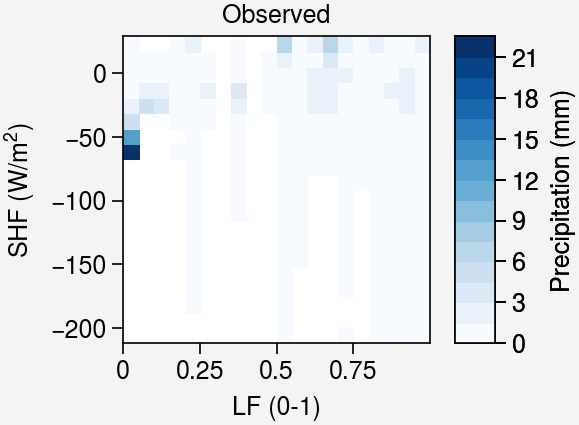

In [28]:
plot_obs_dependence2d('lf','shf')

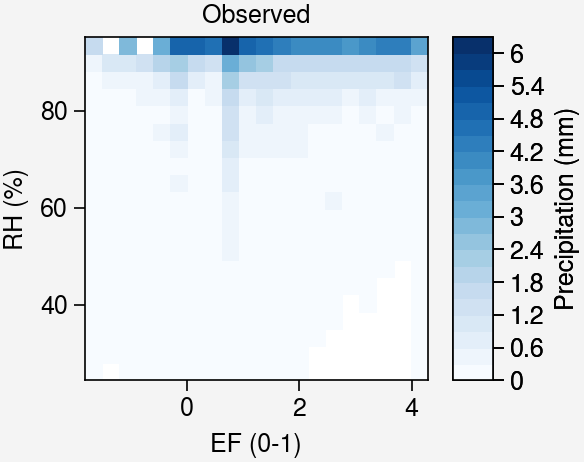

In [29]:
plot_obs_dependence2d('ef','rh')

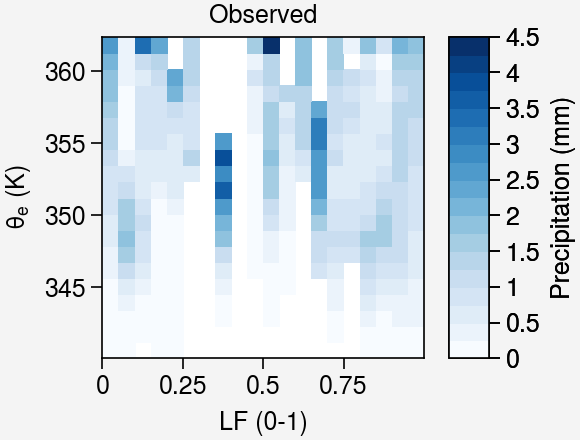

In [30]:
plot_obs_dependence2d('lf','thetae')

## Additional diagnostics: bin occupancy, residual structure, 2D bin differences, sample density, Bowen ratio, and a rotated $\theta_e$ feature

Follow-ups from group feedback: (1) check whether the extreme-$\theta_e$ gap between observations and the NN/SR
curves is a real signal or just sparse bins, (2) look directly at residual structure vs. SHF to see whether any
model is missing a nonlinearity there, (3) difference 2D partial dependence panels against observations directly
(rather than eyeballing side-by-side colorbars) and overlay sample density, (4) look at $1/|\text{Bowen}|$ behavior
and how often Bowen is negative, and (5) build a single rotated $\theta_e/\theta_e^*$ feature along the direction of
maximal joint variance as a candidate for a smaller SR search.

In [33]:
def plot_density(p):
    '''Sample-count histogram over the same value bins used in the 1D partial-dependence plots,
    to flag bins (e.g. at extreme theta_e) where curves are noisy/missing because of sparse data.'''
    x = VARS[p][valid]*STATS[f'{p}_std']+STATS[f'{p}_mean']
    finite   = np.isfinite(x)
    lo,hi    = np.percentile(x[finite],[1,99])
    edges    = np.linspace(lo,hi,NBINS+1)
    counts,_ = np.histogram(x[finite],bins=edges)
    centers  = 0.5*(edges[:-1]+edges[1:])
    fig,ax = pplt.subplots(figwidth=3.2)
    ax.bar(centers,counts,width=0.9*(edges[1]-edges[0]),color='gray7')
    ax.axhline(MINSAMP,color='red',linewidth=1,linestyle='--',label=f'minsamp={MINSAMP}')
    ax.format(grid=False,xlabel=f'{PHYSLABELS[p]} ({PHYSUNITS[p]})',ylabel='Sample count',title=f'Bin occupancy: {PHYSLABELS[p]}')
    ax.legend(loc='ur')
    pplt.show()

def plot_residual_vs(varname):
    '''Bin (observed - predicted) residuals against a raw/derived variable (e.g. SHF), per model,
    to localize where a parametric model's functional form is missing a nonlinearity.'''
    x      = EXTRAVARS[varname][valid]
    models = [name for name in ORDER if name in MODELPRED and varname in MODELPREDICTORS.get(name,[])]
    fig,ax = pplt.subplots(figwidth=3.5)
    ax.axhline(0,color='gray',linewidth=0.8,linestyle='--')
    for name in models:
        resid = obsflat[valid]-MODELPRED[name][valid]
        xc,residbin = bin1d(x,resid)
        ax.plot(xc,residbin,color=COLORS[name],linewidth=1.5,label=LABELS[name])
    ax.format(grid=False,xlabel=f'{EXTRALABELS[varname]} ({EXTRAUNITS[varname]})',
              ylabel='Observed $-$ predicted (mm)',title=f'Residual structure vs {EXTRALABELS[varname]}')
    ax.legend(loc='b',ncols=3)
    pplt.show()

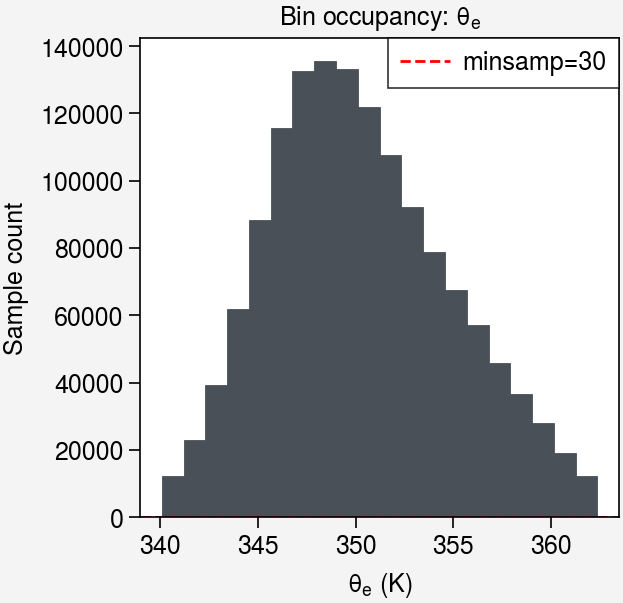

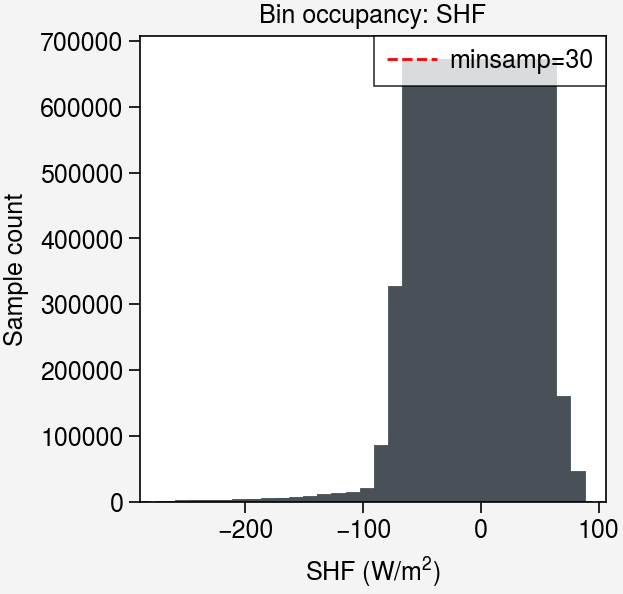

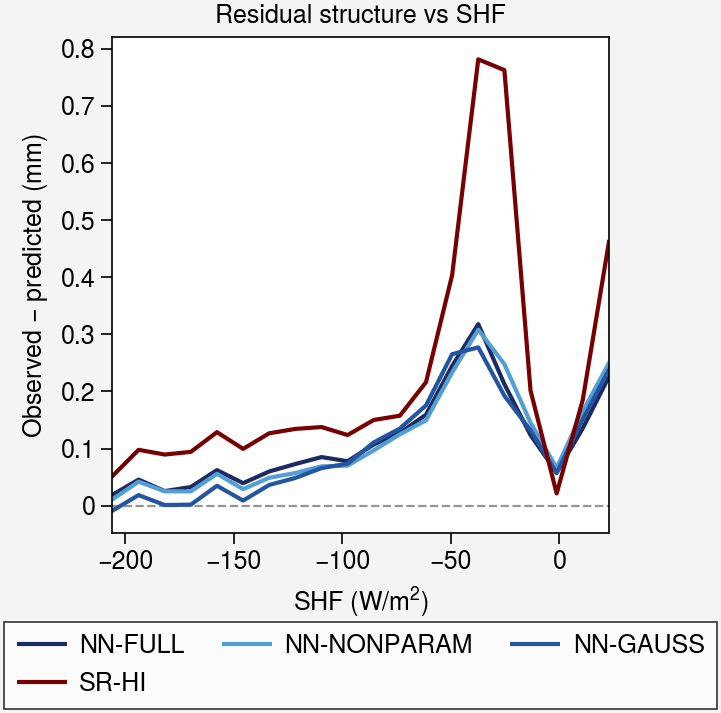

In [34]:
plot_density('thetae')
plot_density('shf')
plot_residual_vs('shf')

In [36]:
def plot_dependence2d_diff(px,py):
    '''2D partial dependence difference (model - observed) on matching bin edges, to localize
    where each model over/under-predicts over (px,py) rather than comparing colorbars by eye.'''
    models = [name for name in ORDER if name in models_for_pair(px,py)]
    x = VARS[px][valid]*STATS[f'{px}_std']+STATS[f'{px}_mean']
    y = VARS[py][valid]*STATS[f'{py}_std']+STATS[f'{py}_mean']
    xc,yc,obsbin2d,_ = bin2d(x,y,obsflat[valid])
    fig,axs = pplt.subplots(nrows=1,ncols=len(models),figwidth=1.6*len(models),share=True)
    if len(models)==1:
        axs = [axs[0]]
    m = None
    for ax,name in zip(axs,models):
        _,_,predbin2d,_ = bin2d(x,y,MODELPRED[name][valid])
        diff = predbin2d-obsbin2d
        m = ax.pcolormesh(xc,yc,diff.T,cmap='Div',vmin=-2,vmax=2,levels=21,extend='both')
        ax.format(title=LABELS[name],xlabel=f'{PHYSLABELS[px]} ({PHYSUNITS[px]})',grid=False)
    axs[0].format(ylabel=f'{PHYSLABELS[py]} ({PHYSUNITS[py]})')
    fig.colorbar(m,loc='r',label='Model $-$ observed (mm)')
    pplt.show()

def plot_dependence2d_density(px,py):
    '''Sample-density companion to plot_dependence2d: how many points back each 2D bin,
    reusing the counts already computed by bin2d.'''
    x = VARS[px][valid]*STATS[f'{px}_std']+STATS[f'{px}_mean']
    y = VARS[py][valid]*STATS[f'{py}_std']+STATS[f'{py}_mean']
    xc,yc,_,counts = bin2d(x,y,obsflat[valid])
    fig,ax = pplt.subplots(figwidth=3.2)
    m = ax.pcolormesh(xc,yc,counts.T,cmap='Greys',norm='log')
    ax.format(title='Sample density',xlabel=f'{PHYSLABELS[px]} ({PHYSUNITS[px]})',
              ylabel=f'{PHYSLABELS[py]} ({PHYSUNITS[py]})',grid=False)
    fig.colorbar(m,loc='r',label='Count')
    pplt.show()

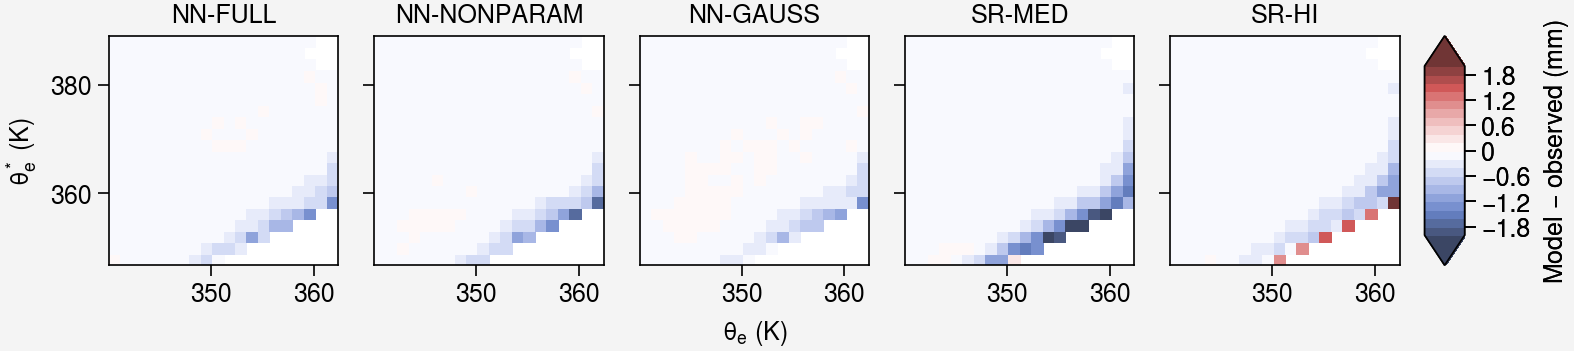

ValueError: Data has no positive values, and therefore can not be log-scaled.

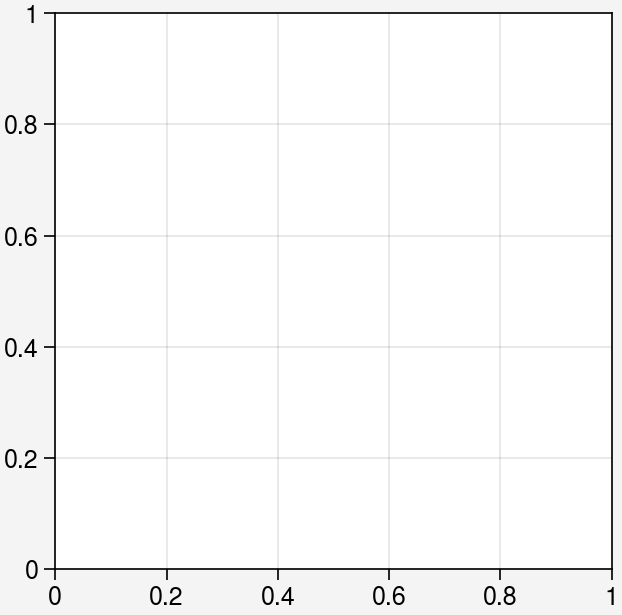

In [37]:
plot_dependence2d_diff('thetae','thetaestar')
plot_dependence2d_density('thetae','thetaestar')

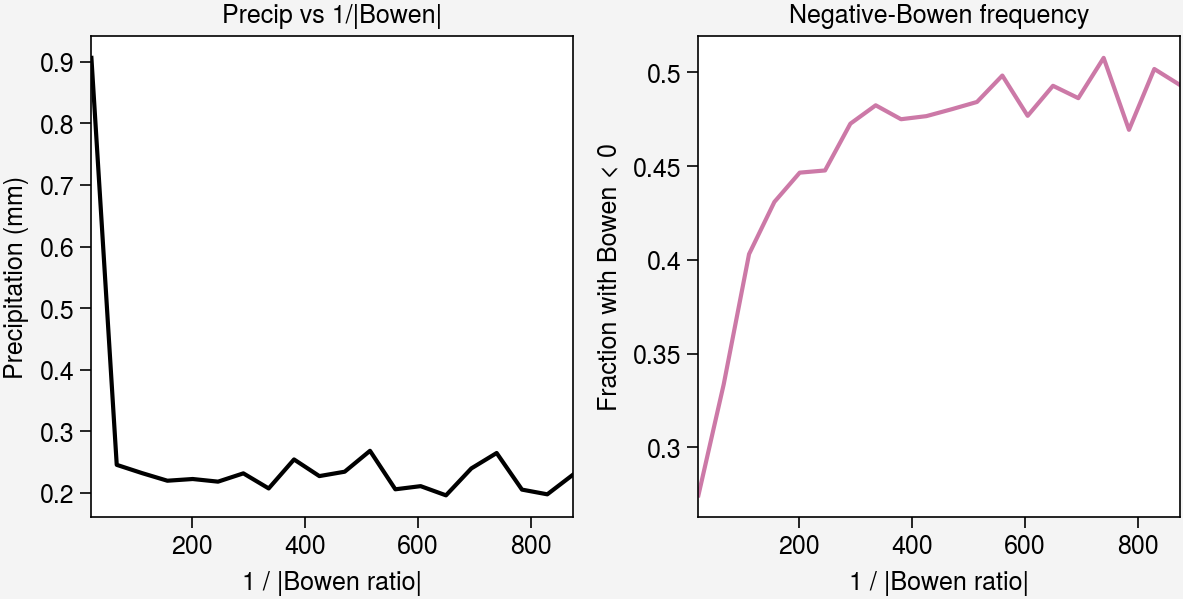

In [38]:
def plot_bowen_analysis(lhfthresh=5.0):
    '''Precipitation dependence on 1/|Bowen ratio| (large when LHF dominates), masking samples
    near LHF=0 where the ratio blows up, plus how often Bowen is negative across the same bins.'''
    lhf   = EXTRAVARS['lhf'][valid]
    bowen = EXTRAVARS['bowen'][valid]
    mask  = np.abs(lhf)>lhfthresh
    invbowen = np.where(mask,1.0/np.abs(bowen),np.nan)

    finite  = np.isfinite(invbowen)
    lo,hi   = np.percentile(invbowen[finite],[1,99])
    edges   = np.linspace(lo,hi,NBINS+1)
    centers = 0.5*(edges[:-1]+edges[1:])
    xi      = np.clip(np.digitize(invbowen,edges)-1,0,NBINS-1)
    obsbin  = np.full(NBINS,np.nan)
    fracneg = np.full(NBINS,np.nan)
    for i in range(NBINS):
        sel = finite&(xi==i)
        if sel.sum()>=MINSAMP:
            obsbin[i]  = obsflat[valid][sel].mean()
            fracneg[i] = (bowen[sel]<0).mean()

    fig,axs = pplt.subplots(nrows=1,ncols=2,figwidth=6,share=False)
    axs[0].plot(centers,obsbin,color='k',linewidth=1.5)
    axs[0].format(grid=False,xlabel='1 / |Bowen ratio|',ylabel='Precipitation (mm)',title='Precip vs 1/|Bowen|')
    axs[1].plot(centers,fracneg,color='C3',linewidth=1.5)
    axs[1].format(grid=False,xlabel='1 / |Bowen ratio|',ylabel='Fraction with Bowen < 0',title='Negative-Bowen frequency')
    pplt.show()

plot_bowen_analysis()

In [40]:
def compute_thetae_rotation():
    '''Leading-eigenvector direction of the (theta_e, theta_e*) covariance: a single feature
    capturing maximal joint variance, as a candidate compact predictor for a smaller SR search.'''
    thetae     = VARS['thetae'][valid]*STATS['thetae_std']+STATS['thetae_mean']
    thetaestar = VARS['thetaestar'][valid]*STATS['thetaestar_std']+STATS['thetaestar_mean']
    X           = np.stack([thetae-thetae.mean(),thetaestar-thetaestar.mean()],axis=1)
    cov         = np.cov(X,rowvar=False)
    evals,evecs = np.linalg.eigh(cov)
    w           = evecs[:,np.argmax(evals)]
    thetaerot   = w[0]*thetae+w[1]*thetaestar
    return thetaerot,w

thetaerot,thetaerotweights = compute_thetae_rotation()
print(f'theta_e rotation weights (theta_e, theta_e*): {thetaerotweights}')

EXTRAVARS['thetae_rot']   = np.full(valid.shape,np.nan)
EXTRAVARS['thetae_rot'][valid] = thetaerot
EXTRAUNITS['thetae_rot']  = 'K'
EXTRALABELS['thetae_rot'] = r'$\theta_e$ rotated'

plot_obs_dependence(['thetae_rot'])
plot_obs_dependence2d('thetae_rot','rh')

theta_e rotation weights (theta_e, theta_e*): [0.22038573 0.9754128 ]


TypeError: plot_obs_dependence() missing 1 required positional argument: 'savepath'